In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    operation1: str
    number2: int
    final_number1: int
    number3: int
    operation2: str
    number4: int
    final_number2: int

In [3]:
def adder1(state:AgentState) -> AgentState:
    """ add two numbers """
    state["final_number1"] = state["number1"] + state["number2"]
    return state

def multiplier1(state:AgentState) -> AgentState:
    """ multiply two numbers """
    state["final_number1"] = state["number1"] * state["number2"]
    return state

def adder2(state:AgentState) -> AgentState:
    """ add two numbers """
    state["final_number2"] = state["number3"] + state["number4"]
    return state

def multiplier2(state:AgentState) -> AgentState:
    """ multiply two numbers """
    state["final_number2"] = state["number3"] * state["number4"]
    return state

def router1(state: AgentState) -> AgentState:
    """ route to the correct operation based on the user's input """
    if state["operation1"] == "+":
        return "add1"
    elif state["operation1"] == "*":
        return "multiply1"
    else:
        raise ValueError("Invalid operation: " + state["operation1"])

def router2(state: AgentState) -> AgentState:
    """ route to the correct operation based on the user's input """
    if state["operation2"] == "+":
        return "add2"
    elif state["operation2"] == "*":
        return "multiply2"
    else:
        raise ValueError("Invalid operation: " + state["operation2"])

In [5]:
graph = StateGraph(AgentState)

graph.add_node("router_node1", lambda state: state)  # pass-through node to route to the first operation
graph.add_node("add_node1", adder1)
graph.add_node("multiply_node1", multiplier1)
graph.add_node("router_node2", lambda state: state)  # pass-through node to route to the second operation
graph.add_node("add_node2", adder2)
graph.add_node("multiply_node2", multiplier2)

graph.add_edge(START, "router_node1")
graph.add_conditional_edges(
    "router_node1",
    router1,
    {
        "add1": "add_node1",
        "multiply1": "multiply_node1"
    }
)
graph.add_edge("add_node1", "router_node2")
graph.add_edge("multiply_node1", "router_node2")
graph.add_conditional_edges(
    "router_node2",
    router2,
    {
        "add2": "add_node2",
        "multiply2": "multiply_node2"
    }
)
graph.add_edge("add_node2", END)
graph.add_edge("multiply_node2", END)   

app = graph.compile()

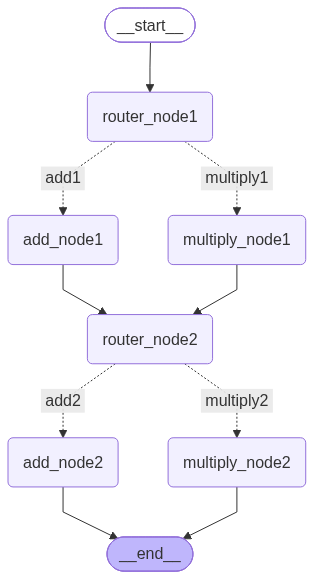

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # display the graph as an image in the notebook

In [7]:
input = AgentState(number1=5, operation1="+", number2=10, final_number1=0, number3=3, operation2="*", number4=4, final_number2=0)  # create an initial state for the graph
ans = app.invoke(input)  # invoke the graph with the initial state

In [8]:
ans

{'number1': 5,
 'operation1': '+',
 'number2': 10,
 'final_number1': 15,
 'number3': 3,
 'operation2': '*',
 'number4': 4,
 'final_number2': 12}